### Import Libraries

In [66]:
# data manipulation
import pandas as pd 
import numpy as np

# models
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score


import os; os.chdir('/Users/aadityaparanjape/Downloads/IDX Exchange/') # DELETE THIS WHEN FINISHED

# results visualizations
from matplotlib import pyplot as plt
import seaborn as sns; sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

### Load Splits

In [59]:
# load data for splits
train_data = pd.read_csv('data/train_set_unscaled.csv')
test_data = pd.read_csv('data/test_set_unscaled.csv')

# train
X_train = train_data.drop(columns=['logClosePrice', 'ClosePrice'])
y_train = train_data['ClosePrice']
y_train_log = train_data['logClosePrice']

# test 
X_test = test_data.drop(columns=['logClosePrice', 'ClosePrice'])
y_test = test_data['ClosePrice']
y_test_log = test_data['logClosePrice']

### Initialize and fit models with logClosePrice

In [60]:
dt = DecisionTreeRegressor(random_state=54)
dt_log = DecisionTreeRegressor(random_state=54)

rf = RandomForestRegressor(n_estimators=100, random_state=54) 
rf_log = RandomForestRegressor(n_estimators=100, random_state=54) 

# fit models
dt.fit(X_train, y_train)
dt_log.fit(X_train, y_train_log)

rf.fit(X_train, y_train)
rf_log.fit(X_train, y_train_log)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
# # tuning Decision Tree
# dt_params = {
#     'max_depth': randint(3, 20),
#     'min_samples_split': randint(2, 20),
#     'min_samples_leaf': randint(1, 10)
# }
# dt_random = RandomizedSearchCV(DecisionTreeRegressor(random_state=54), dt_params,
#                                n_iter=50, cv=5, scoring='r2', n_jobs=-1, random_state=54)
# dt_random.fit(X_train, y_train)
# print('Best DT params:', dt_random.best_params_)

# # tuning Random Forest model
# rf_params = {
#     'n_estimators': randint(100, 500),
#     'max_depth': randint(5, 30),
#     'min_samples_split': randint(2, 20),
#     'min_samples_leaf': randint(1, 10)
# }

# rf_random = RandomizedSearchCV(RandomForestRegressor(random_state=45), rf_params,
#                                n_iter=50, cv=5, scoring='r2', n_jobs=-1, random_state=45)
# rf_random.fit(X_train, y_train)
# print('Best RF params:', rf_random.best_params_)

# # use the best models for evaluation
# dt_best = dt_random.best_estimator_
# rf_best = rf_random.best_estimator_

### Make Predictions

In [61]:
# dt_preds = dt_best.predict(X_test)
# rf_preds = rf_best.predict(X_test)

dt_preds = dt.predict(X_test)
dt_log_preds = dt_log.predict(X_test)

rf_preds = rf.predict(X_test)
rf_log_preds = rf_log.predict(X_test)

### Evaluate Model

In [62]:
models = {
    'Decision Tree Model' : (dt_preds, False),
    'Decision Tree Model (log transformed target)': (dt_log_preds, True),
    'Random Forest Model': (rf_preds, False),
    'Random Forest Model (log transformed target)': (rf_log_preds, True)   
}

# print output
for model, (pred, log_transformed) in models.items():
    if log_transformed:
        print(f'R^2 score for {model}: {round(r2_score(y_test_log, pred), 4)}')
    else:
        print(f'R^2 score for {model}: {round(r2_score(y_test, pred), 4)}')

R^2 score for Decision Tree Model: 0.5473
R^2 score for Decision Tree Model (log transformed target): 0.8222
R^2 score for Random Forest Model: 0.7282
R^2 score for Random Forest Model (log transformed target): 0.9057


### Visualize Results for Decision Tree Model

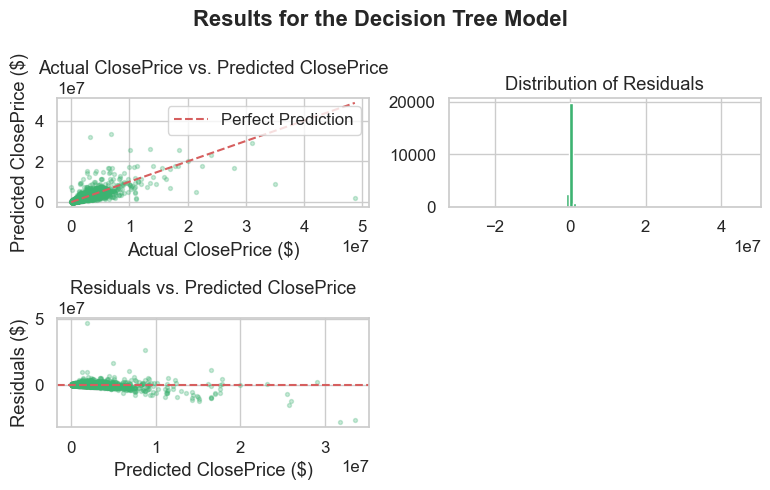

In [52]:
fig, axes = plt.subplots(2,2, figsize=(8,5))
fig.suptitle('Results for the Decision Tree Model', fontweight = "bold")

# actual vs predicted scatter plot
axes[0,0].scatter(y_test, dt_preds, alpha=0.15, s=8, color='mediumseagreen')
axes[0,0].plot([0, max(y_test.max(), dt_preds.max())], [0, max(y_test.max(), dt_preds.max())], 
               color='r', ls = '--', label = 'Perfect Prediction')
axes[0,0].set_xlabel('Actual ClosePrice ($)')
axes[0,0].set_ylabel('Predicted ClosePrice ($)')
axes[0,0].set_title('Actual ClosePrice vs. Predicted ClosePrice')
axes[0,0].legend()

# distribution of residuals
residuals = y_test - dt_preds
axes[0,1].hist(residuals, bins=80, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Distribution of Residuals')

# Residuals vs Predicted ClosePrice
axes[1,0].scatter(dt_preds, residuals, color='mediumseagreen', alpha=0.15, s=8)
axes[1,0].axhline(0, color='r', ls='--')
axes[1,0].set_title('Residuals vs. Predicted ClosePrice')
axes[1,0].set_xlabel('Predicted ClosePrice ($)')
axes[1,0].set_ylabel('Residuals ($)')

# make final quadrant invisible 
axes[1,1].set_visible(False)

plt.tight_layout(); plt.show()

### Visualize Results for Decision Tree Model (log transfored target)

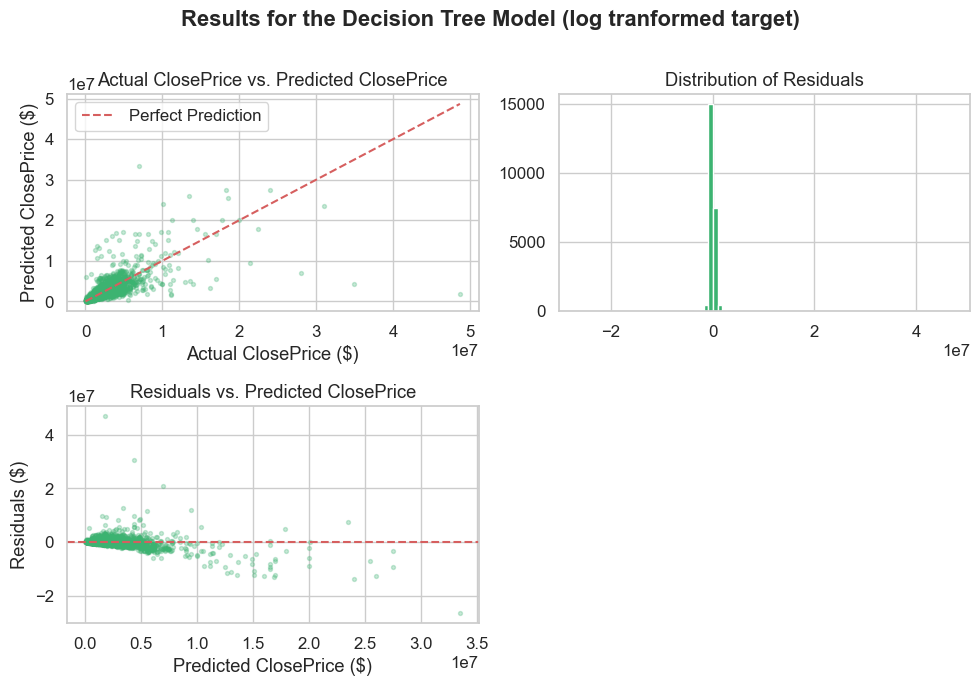

In [70]:
fig, axes = plt.subplots(2,2, figsize=(10,7))
fig.suptitle('Results for the Decision Tree Model (log-tranformed target)', fontweight = "bold")
dt_log_preds_exp = np.exp(dt_log_preds) # reset predictions back to normal scale

# actual vs predicted scatter plot
axes[0,0].scatter(y_test, dt_log_preds_exp, alpha=0.15, s=8, color='mediumseagreen')
axes[0,0].plot([0, max(y_test.max(), dt_log_preds_exp.max())], [0, max(y_test.max(), dt_log_preds_exp.max())], 
               color='r', ls = '--', label = 'Perfect Prediction')
axes[0,0].set_xlabel('Actual ClosePrice ($)')
axes[0,0].set_ylabel('Predicted ClosePrice ($)')
axes[0,0].set_title('Actual ClosePrice vs. Predicted ClosePrice')
axes[0,0].legend()

# distribution of residuals
residuals = y_test - dt_log_preds_exp
axes[0,1].hist(residuals, bins=80, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Distribution of Residuals')

# Residuals vs Predicted ClosePrice
axes[1,0].scatter(dt_log_preds_exp, residuals, color='mediumseagreen', alpha=0.15, s=8)
axes[1,0].axhline(0, color='r', ls='--')
axes[1,0].set_title('Residuals vs. Predicted ClosePrice')
axes[1,0].set_xlabel('Predicted ClosePrice ($)')
axes[1,0].set_ylabel('Residuals ($)')

# make final quadrant invisible 
axes[1,1].set_visible(False)

plt.tight_layout(); plt.show()

### Visualize Results for Random Forest Model

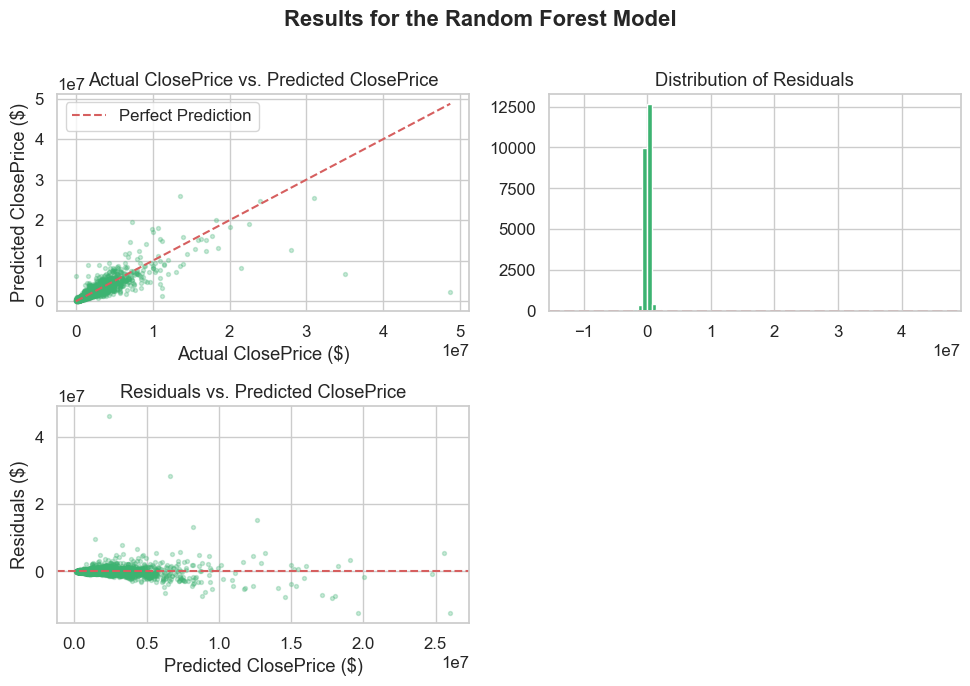

In [72]:
fig, axes = plt.subplots(2,2, figsize=(10,7))
fig.suptitle('Results for the Random Forest Model', fontweight = 'bold')

# actual vs predicted scatter plot
axes[0,0].scatter(y_test, rf_preds, alpha=0.15, s=8, color='mediumseagreen')
axes[0,0].plot([0, max(y_test.max(), rf_preds.max())], [0, max(y_test.max(), rf_preds.max())], 
               color='r', ls = '--', label = 'Perfect Prediction')
axes[0,0].set_xlabel('Actual ClosePrice ($)')
axes[0,0].set_ylabel('Predicted ClosePrice ($)')
axes[0,0].set_title('Actual ClosePrice vs. Predicted ClosePrice')
axes[0,0].legend()

# distribution of residuals
residuals = y_test - rf_preds
axes[0,1].hist(residuals, bins=80, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Distribution of Residuals')
axes[0,1].axhline(0, color='r', ls='--', lw=2)

# Residuals vs Predicted ClosePrice
axes[1,0].scatter(rf_preds, residuals, color='mediumseagreen', alpha=0.15, s=8)
axes[1,0].axhline(0, color='r', ls='--')
axes[1,0].set_title('Residuals vs. Predicted ClosePrice')
axes[1,0].set_xlabel('Predicted ClosePrice ($)')
axes[1,0].set_ylabel('Residuals ($)')

# make final quadrant invisible
axes[1,1].set_visible(False)

plt.tight_layout(); plt.show()

### Visualize Results for Random Forest Model (log-transformed target)

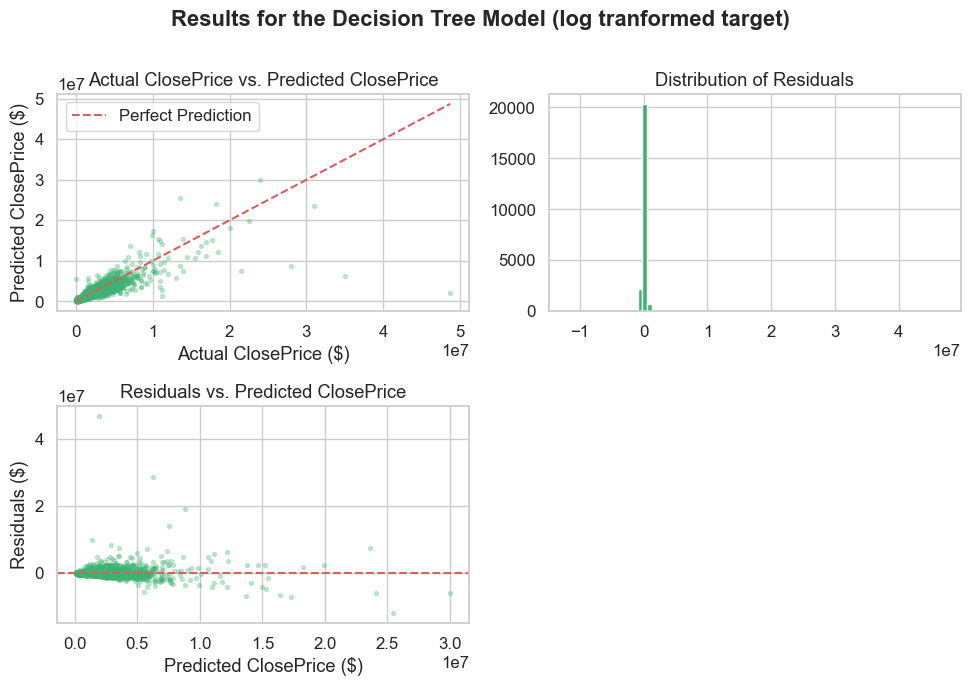

In [71]:
fig, axes = plt.subplots(2,2, figsize=(10,7))
fig.suptitle('Results for the Decision Tree Model (log-tranformed target)', fontweight = "bold")
rf_log_preds_exp = np.exp(rf_log_preds) # reset predictions back to normal scale

# actual vs predicted scatter plot
axes[0,0].scatter(y_test, rf_log_preds_exp, alpha=0.15, s=8, color='mediumseagreen')
axes[0,0].plot([0, max(y_test.max(), rf_log_preds_exp.max())], [0, max(y_test.max(), rf_log_preds_exp.max())], 
               color='r', ls = '--', label = 'Perfect Prediction')
axes[0,0].set_xlabel('Actual ClosePrice ($)')
axes[0,0].set_ylabel('Predicted ClosePrice ($)')
axes[0,0].set_title('Actual ClosePrice vs. Predicted ClosePrice')
axes[0,0].legend()

# distribution of residuals
residuals = y_test - rf_log_preds_exp
axes[0,1].hist(residuals, bins=80, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Distribution of Residuals')

# Residuals vs Predicted ClosePrice
axes[1,0].scatter(rf_log_preds_exp, residuals, color='mediumseagreen', alpha=0.15, s=8)
axes[1,0].axhline(0, color='r', ls='--')
axes[1,0].set_title('Residuals vs. Predicted ClosePrice')
axes[1,0].set_xlabel('Predicted ClosePrice ($)')
axes[1,0].set_ylabel('Residuals ($)')

# make final quadrant invisible 
axes[1,1].set_visible(False)

plt.tight_layout(); plt.show()

### Summary of Model Behavior

| Model | R^2 Score |
|---|---|
| Linear | 0.8439 |
| Decision Tree | 0.5473 |
| Decision Tree Model (log transformed target) | 0.8222 |
| Random Forest | 0.7282 |
| Random Forest Model (log transformed target) | 0.9057 |

- As expected, Random Forest model outperforms Decision Tree model
- Both Decision Tree models and the standard Random Forest model do not outperform Linear model, but the log-transformed Random Forest Model does
- With both Decision Tree and Random Forest models, residuals increase as ClosePrice increases, indicating a lack of accuracy with listings on the high end of ClosePrice
- For both models above, residuals appear to be normally distributed